In [1]:
source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [2]:
meta = fread('../results/rna/mapping/sample_metadata_after_mapping.txt.gz') %>%
    .[doublet_call == FALSE & pass_rnaQC == TRUE]


In [3]:
io$rna.sce

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/06_Runx1_RNA/processed/SingleCellExperiment.rds"

In [4]:
sce = load_SingleCellExperiment(io$rna.sce, cells=meta$cell, normalise=TRUE)

In [5]:
sce

class: SingleCellExperiment 
dim: 29453 34893 
metadata(0):
assays(2): counts logcounts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(34893): SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1
  SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1 ...
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGAGGATTTAG-1
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGCAAGTACCT-1
colData names(9): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [7]:
meta$tdTom = as.vector(logcounts(sce['tomato-td', ]))
meta$runx1 = as.vector(logcounts(sce['Runx1', ]))


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'logcounts': object 'sce' not found


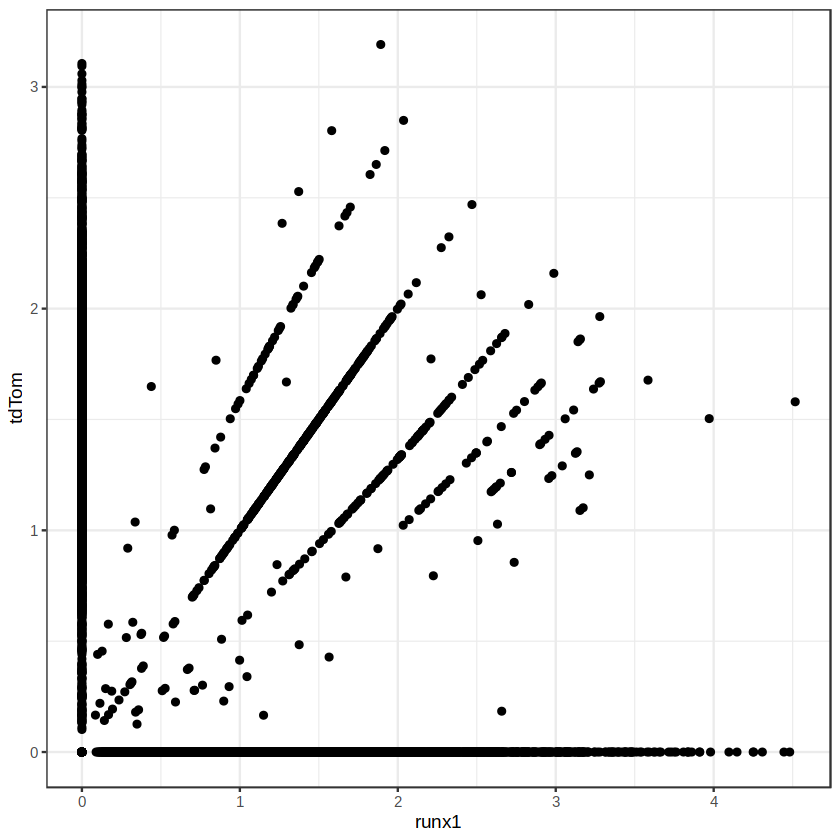

In [22]:
ggplot(meta, aes(runx1, tdTom)) + 
    geom_point() + 
    theme_bw()

In [6]:
head(meta)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,stage,pass_rnaQC,doublet_score,doublet_call,celltype.mapped_mnn,celltype.score_mnn,closest.cell_mnn
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1,AAACGAACAATTGCAC-1,SLX-21184_SITTA7_H5NKNDMXY,5488,57471,2.47,28.42,SLX-21184,TRUE,0.26,FALSE,Erythroid3,1.00,cell_40571
SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1,AAACGAACACCAGCTG-1,SLX-21184_SITTA7_H5NKNDMXY,6686,110322,1.80,30.12,SLX-21184,TRUE,0.33,FALSE,Erythroid2,0.80,cell_64311
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACAGACAGTCG-1,AAAGAACAGACAGTCG-1,SLX-21184_SITTA7_H5NKNDMXY,6496,52477,1.78,21.48,SLX-21184,TRUE,0.22,FALSE,Surface_ectoderm,1.00,cell_133268
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCAAATGATG-1,AAAGAACCAAATGATG-1,SLX-21184_SITTA7_H5NKNDMXY,5560,64657,2.83,30.18,SLX-21184,TRUE,0.27,FALSE,Erythroid3,0.96,cell_138786
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACCACTTTATC-1,AAAGAACCACTTTATC-1,SLX-21184_SITTA7_H5NKNDMXY,2986,8690,0.12,17.25,SLX-21184,TRUE,0.02,FALSE,ExE_ectoderm,1.00,cell_95520
SLX-21184_SITTA7_H5NKNDMXY#AAAGAACGTATGGGAC-1,AAAGAACGTATGGGAC-1,SLX-21184_SITTA7_H5NKNDMXY,6594,100108,2.76,29.42,SLX-21184,TRUE,0.69,FALSE,Erythroid3,0.84,cell_93369


In [9]:
sce

class: SingleCellExperiment 
dim: 29453 34893 
metadata(0):
assays(1): counts
rownames(29453): Xkr4 Gm1992 ... CAAA01147332.1 tomato-td
rowData names(0):
colnames(34893): SLX-21184_SITTA7_H5NKNDMXY#AAACGAACAATTGCAC-1
  SLX-21184_SITTA7_H5NKNDMXY#AAACGAACACCAGCTG-1 ...
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGAGGATTTAG-1
  SLX-21184_SITTH10_H5NKNDMXY#TTTGTTGCAAGTACCT-1
colData names(9): barcode sample ... pass_rnaQC sizeFactor
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [13]:
opts$celltype.colors

Epiblast               Primitive_Streak 
                     "#635547"                      "#DABE99" 
               Caudal_epiblast                            PGC 
                     "#9e6762"                      "#FACB12" 
     Anterior_Primitive_Streak                      Notochord 
                     "#c19f70"                      "#0F4A9C" 
                 Def._endoderm                            Gut 
                     "#F397C0"                      "#EF5A9D" 
              Nascent_mesoderm                 Mixed_mesoderm 
                     "#C594BF"                      "#DFCDE4" 
         Intermediate_mesoderm                Caudal_Mesoderm 
                     "#139992"                      "#3F84AA" 
             Paraxial_mesoderm               Somitic_mesoderm 
                     "#8DB5CE"                      "#005579" 
           Pharyngeal_mesoderm                 Cardiomyocytes 
                     "#C9EBFB"                      "#B51D8D" 
                     Allantois                   ExE_mesoderm 
                     "#532C8A"                      "#8870ad" 
                    Mesenchyme Haematoendothelial_progenitors 
                     "#cc7818"                      "#FBBE92" 
                   Endothelium              Blood_progenitors 
                     "#ff891c"                      "#c9a997" 
           Blood_progenitors_1            Blood_progenitors_2 
                     "#f9decf"                      "#c9a997" 
                     Erythroid                     Erythroid1 
                     "#EF4E22"                      "#C72228" 
                    Erythroid2                     Erythroid3 
                     "#f79083"                      "#EF4E22" 
                           NMP                   Neurectoderm 
                     "#8EC792"                      "#65A83E" 
          Rostral_neurectoderm            Caudal_neurectoderm 
                     "#65A83E"                      "#354E23" 
                  Neural_crest   Forebrain_Midbrain_Hindbrain 
                     "#C3C388"                      "#647a4f" 
                   Spinal_cord               Surface_ectoderm 
                     "#CDE088"                      "#f7f79e" 
             Visceral_endoderm                   ExE_endoderm 
                     "#F6BFCB"                      "#7F6874" 
                  ExE_ectoderm              Parietal_endoderm 
                     "#989898"                      "#1A1A1A"

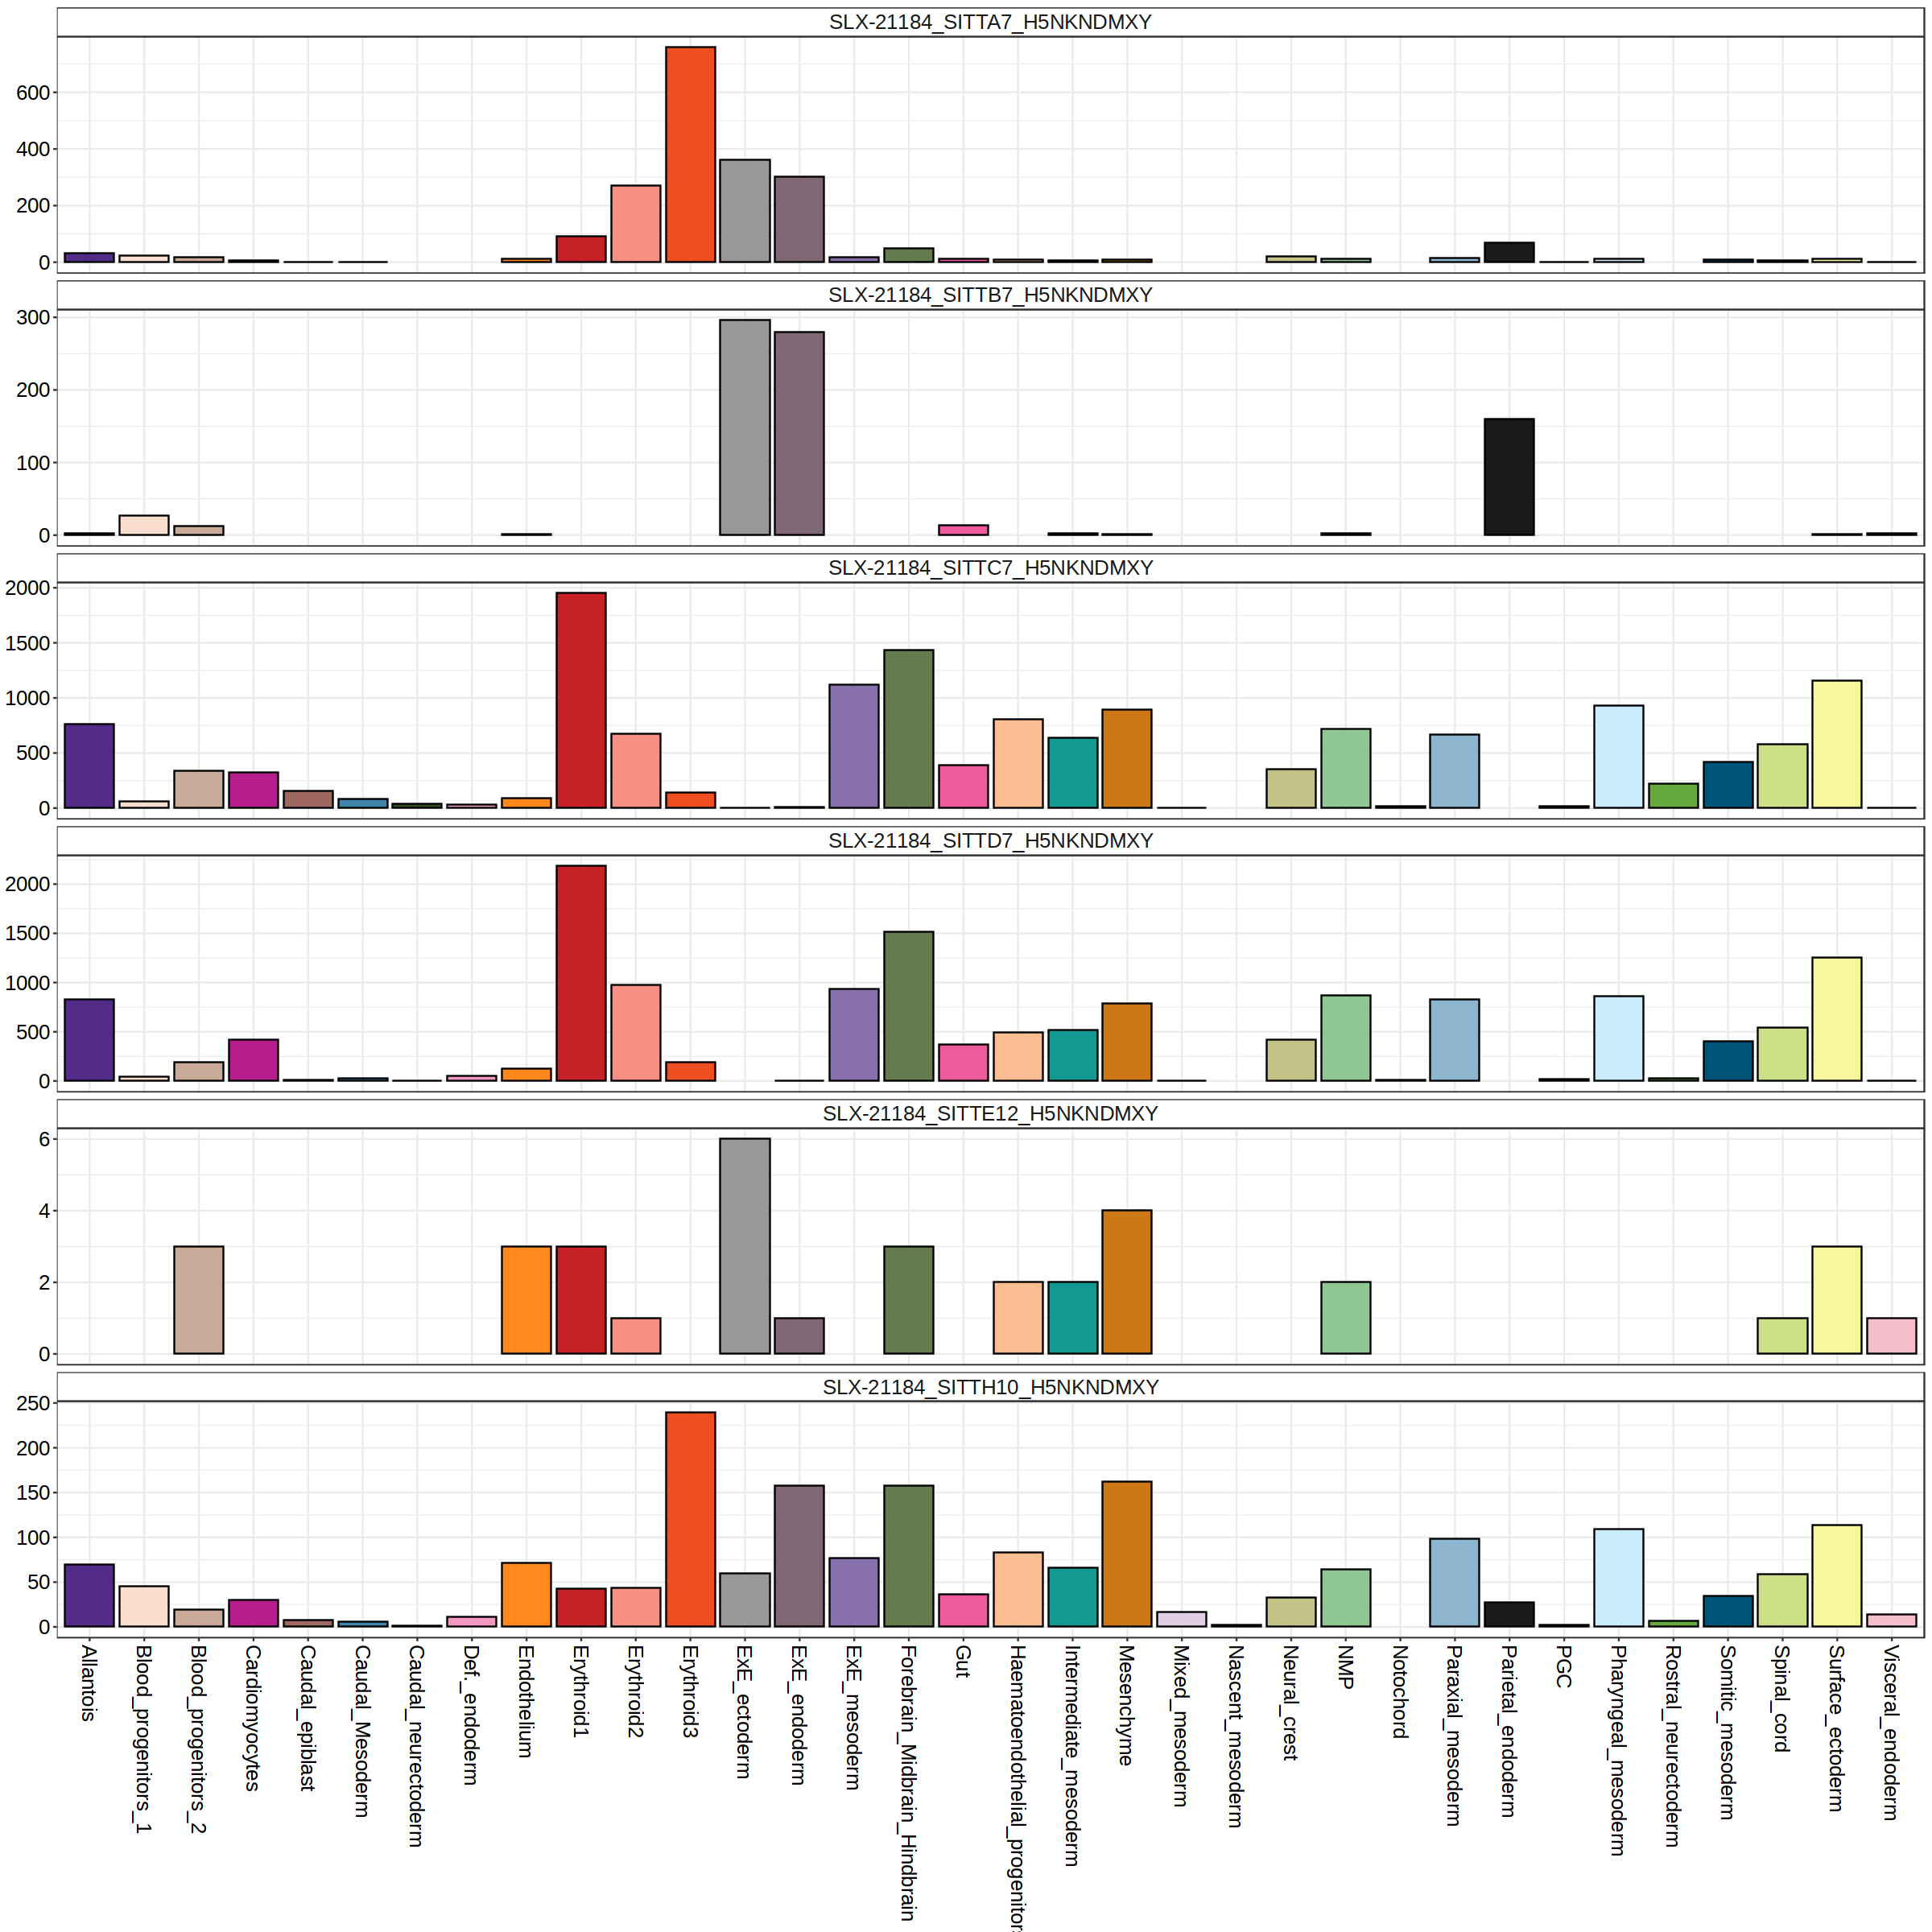

In [18]:
options(repr.plot.width=20, repr.plot.height=20)
ggplot(meta, aes(celltype.mapped_mnn, fill = celltype.mapped_mnn)) + 
    geom_bar(color='black') + 
    facet_wrap(~sample, ncol=1, scales='free_y') + 
    scale_fill_manual(values=opts$celltype.colors) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          strip.background = element_rect(fill='white'),
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size=15),
          axis.title = element_blank(),
          legend.position = 'none')

In [19]:
atlas_meta = fread(io$rna.atlas.metadata)

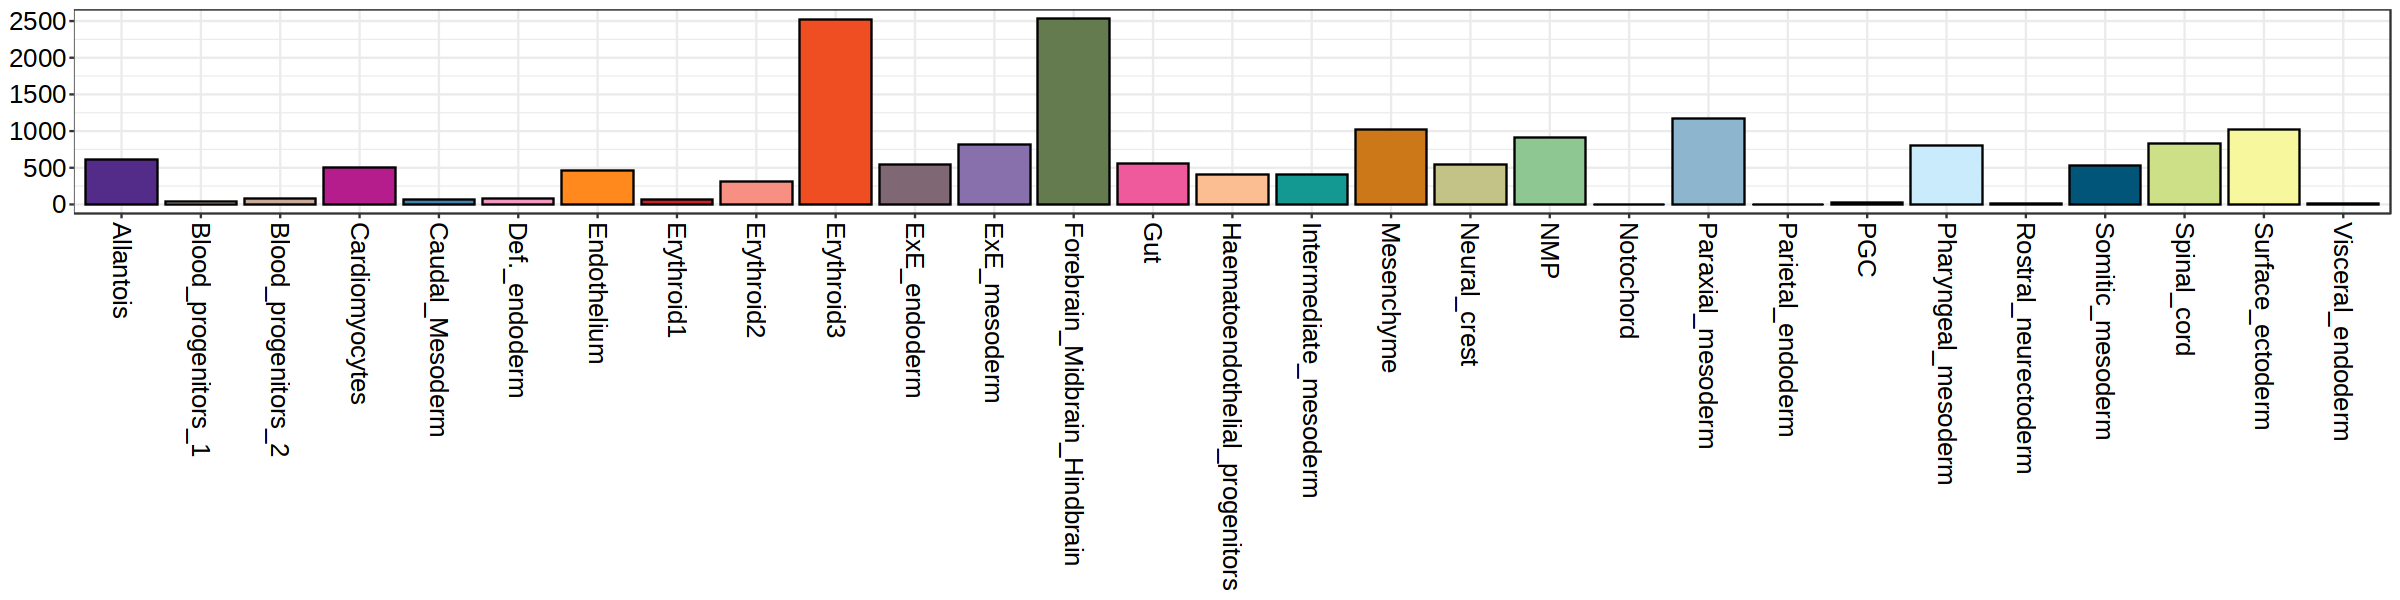

In [24]:
options(repr.plot.width=20, repr.plot.height=5)

ggplot(atlas_meta[stage=='E8.5'], aes(celltype, fill = celltype)) + 
    geom_bar(color='black') + 
   # facet_wrap(~sample, ncol=1, scales='free_y') + 
    scale_fill_manual(values=opts$celltype.colors) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          strip.background = element_rect(fill='white'),
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size=15),
          axis.title = element_blank(),
          legend.position = 'none')

In [25]:
unique(meta$sample)

[1] "SLX-21184_SITTA7_H5NKNDMXY"  "SLX-21184_SITTB7_H5NKNDMXY" 
[3] "SLX-21184_SITTC7_H5NKNDMXY"  "SLX-21184_SITTD7_H5NKNDMXY" 
[5] "SLX-21184_SITTE12_H5NKNDMXY" "SLX-21184_SITTH10_H5NKNDMXY"

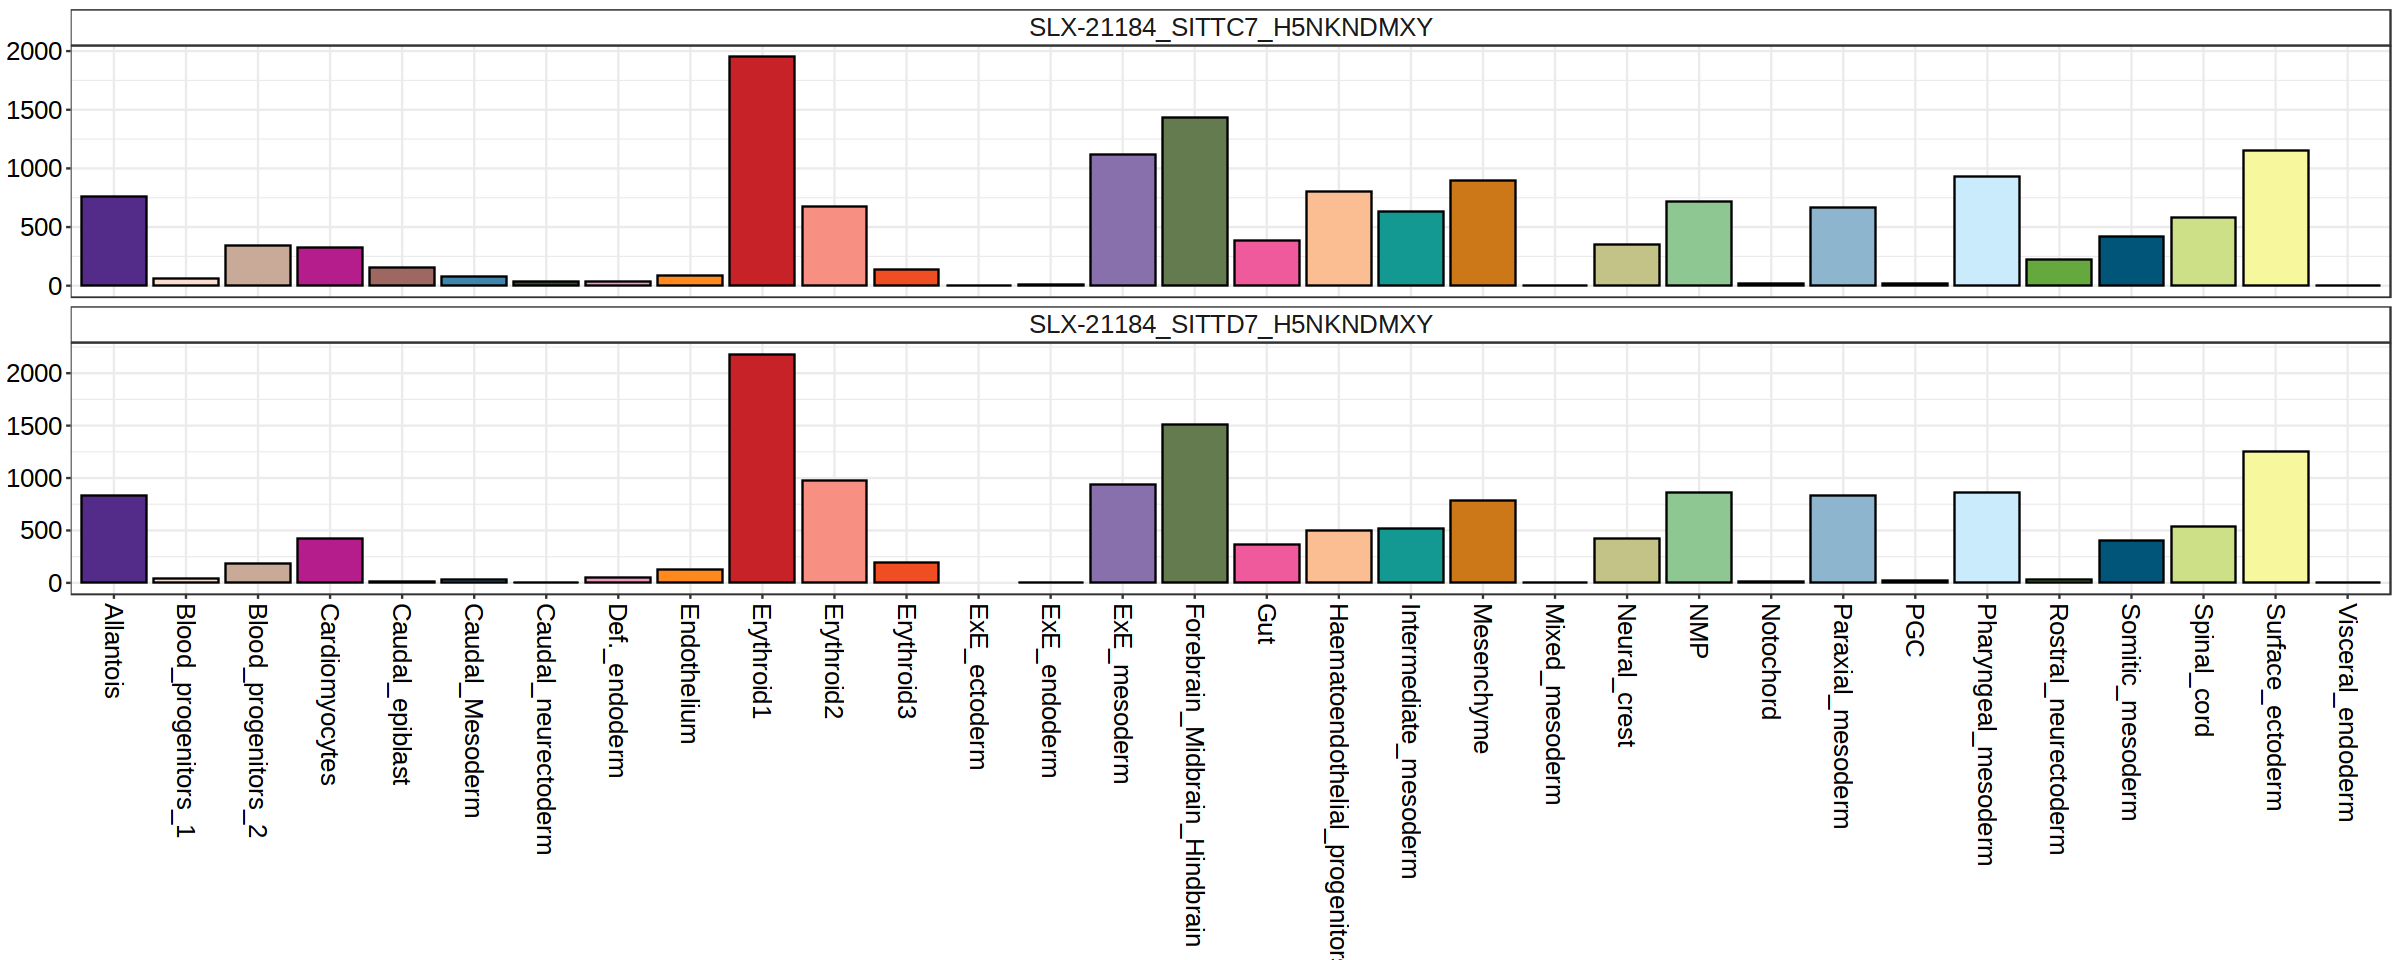

In [28]:
options(repr.plot.width=20, repr.plot.height=8)
ggplot(meta[sample %in% c('SLX-21184_SITTC7_H5NKNDMXY','SLX-21184_SITTD7_H5NKNDMXY')], aes(celltype.mapped_mnn, fill = celltype.mapped_mnn)) + 
    geom_bar(color='black') + 
    facet_wrap(~sample, ncol=1, scales='free_y') + 
    scale_fill_manual(values=opts$celltype.colors) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          strip.background = element_rect(fill='white'),
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size=15),
          axis.title = element_blank(),
          legend.position = 'none')